Initial Parameters (Random):
W1:
 [[-0.25091976  0.90142861]
 [ 0.46398788  0.19731697]]
b1:
 [[-0.68796272 -0.68801096]]
W2:
 [[-0.88383278]
 [ 0.73235229]]
b2:
 [[0.20223002]]

Training XOR Neural Network...
Iteration     0: Loss = 0.5006
Iteration  5000: Loss = 0.2185

Training Complete!

Predictions (XOR Gate):
Input: [0 0] → Pred: 0.062 (0)
Input: [0 1] → Pred: 0.944 (1)
Input: [1 0] → Pred: 0.944 (1)
Input: [1 1] → Pred: 0.059 (0)


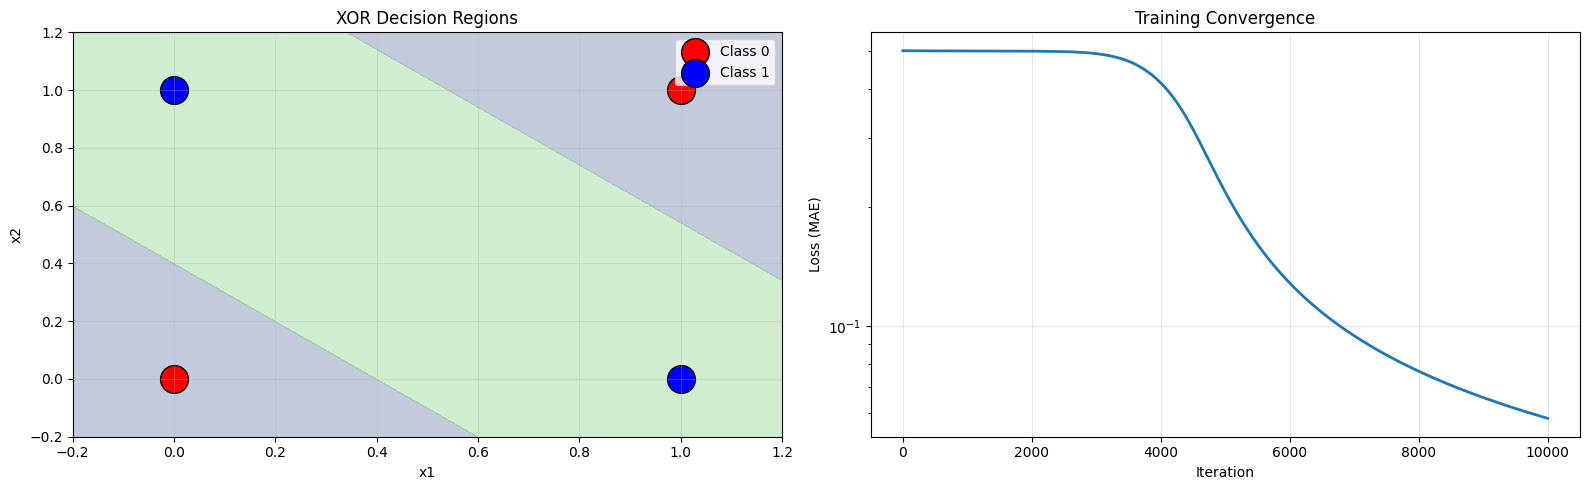

In [1]:
# XOR GATE WITH RANDOM INITIALIZATION (2-Layer Neural Network)
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
input_size = 2
hidden_size = 2
output_size = 1
learning_rate = 0.1
iterations = 10000
print_interval = 5000

# XOR Dataset (FIXED)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# -------- RANDOM INITIALIZATION --------
np.random.seed(42)
W1 = np.random.uniform(-1, 1, (input_size, hidden_size))
b1 = np.random.uniform(-1, 1, (1, hidden_size))
W2 = np.random.uniform(-1, 1, (hidden_size, output_size))
b2 = np.random.uniform(-1, 1, (1, output_size))

print("Initial Parameters (Random):")
print("W1:\n", W1)
print("b1:\n", b1)
print("W2:\n", W2)
print("b2:\n", b2)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

# -------- TRAINING --------
loss_history = []
print("\nTraining XOR Neural Network...")

for iteration in range(iterations):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    output = sigmoid(z2)

    # Error
    error = y - output
    loss = np.mean(np.abs(error))
    loss_history.append(loss)

    # Backpropagation
    d_output = error * sigmoid_derivative(output)
    d_hidden = np.dot(d_output, W2.T) * sigmoid_derivative(a1)

    # Update weights
    W2 += learning_rate * np.dot(a1.T, d_output)
    b2 += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    W1 += learning_rate * np.dot(X.T, d_hidden)
    b1 += learning_rate * np.sum(d_hidden, axis=0, keepdims=True)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration:5d}: Loss = {loss:.4f}")

print("\nTraining Complete!")

# -------- PREDICTIONS --------
print("\nPredictions (XOR Gate):")
final_output = sigmoid(np.dot(sigmoid(np.dot(X, W1) + b1), W2) + b2)

for i in range(len(X)):
    pred_class = 1 if final_output[i, 0] > 0.5 else 0
    print(f"Input: {X[i]} → Pred: {final_output[i,0]:.3f} ({pred_class})")

# ------------------ PLOTTING ------------------
plt.figure(figsize=(16, 5))

# Decision Regions
plt.subplot(1, 2, 1)
xx, yy = np.meshgrid(
    np.linspace(-0.2, 1.2, 300),
    np.linspace(-0.2, 1.2, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

z1 = sigmoid(np.dot(grid, W1) + b1)
z2 = sigmoid(np.dot(z1, W2) + b2)
Z = z2.reshape(xx.shape)

plt.contourf(xx, yy, Z > 0.5, alpha=0.3)
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
            s=400, c='red', edgecolors='black', label='Class 0')
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
            s=400, c='blue', edgecolors='black', label='Class 1')

plt.title("XOR Decision Regions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Curve
plt.subplot(1, 2, 2)
plt.semilogy(loss_history, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Loss (MAE)")
plt.title("Training Convergence")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
